<a href="https://colab.research.google.com/github/oliveirangel/projetos_pandas-python/blob/main/Analise_Mag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [ ]:
Base_Mag = pd.read_excel('Dados-Magalu.xlsx')

Base_Mag.head()

,Data,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
0,2021-01-04,25.580000,24.870001,25.260000,25.200001,25706100,25.181740
1,2021-01-05,25.180000,24.340000,25.100000,24.760000,25431900,24.742058
2,2021-01-06,24.660000,23.420000,24.650000,23.459999,51799000,23.442999
3,2021-01-07,23.850000,22.950001,23.639999,23.160000,42146600,23.143217
4,2021-01-08,24.299999,23.020000,23.190001,23.840000,43988100,23.822723


In [ ]:
Base_Mag.shape

(247, 7)

In [ ]:
Base_Mag.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Data        247 non-null    datetime64[ns]
 1   Maior       247 non-null    float64       
 2   Menor       247 non-null    float64       
 3   Abertura    247 non-null    float64       
 4   Fechamento  247 non-null    float64       
 5   Volume      247 non-null    int64         
 6   Adj Close   247 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 13.6 KB


In [ ]:
Dados = Base_Mag.set_index('Data')

Dados.head()

,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
Data,,,,,,
2021-01-04,25.580000,24.870001,25.260000,25.200001,25706100,25.181740
2021-01-05,25.180000,24.340000,25.100000,24.760000,25431900,24.742058
2021-01-06,24.660000,23.420000,24.650000,23.459999,51799000,23.442999
2021-01-07,23.850000,22.950001,23.639999,23.160000,42146600,23.143217
2021-01-08,24.299999,23.020000,23.190001,23.840000,43988100,23.822723


Text(0, 0.5, 'Valor da Ação')

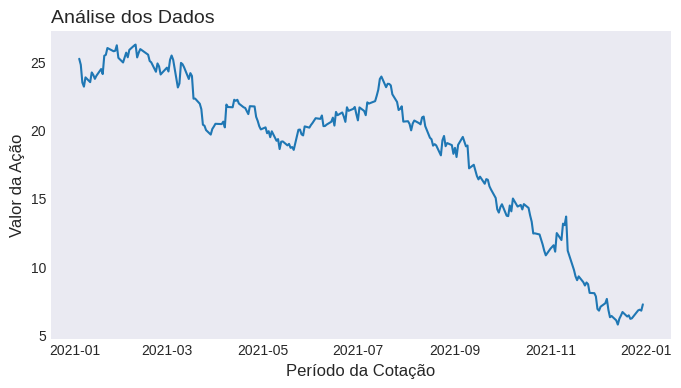

In [ ]:
plt.figure(figsize=(8,4))
plt.style.use('seaborn-v0_8-dark')
plt.plot(Dados.index, Dados['Fechamento'])
plt.title('Análise dos Dados', fontsize= 14, loc='left');
plt.xlabel('Período da Cotação', fontsize= 12)
plt.ylabel('Valor da Ação', fontsize= 12)


In [ ]:
Dados.tail()

,Maior,Menor,Abertura,Fechamento,Volume,Adj Close
Data,,,,,,
2021-12-23,6.34,5.99,6.22,6.20,97106100,6.20
2021-12-27,6.78,6.23,6.23,6.78,124279800,6.78
2021-12-28,6.96,6.64,6.79,6.83,165573900,6.83
2021-12-29,6.90,6.70,6.84,6.76,79247400,6.76
2021-12-30,7.41,6.77,6.80,7.22,180329400,7.22


Text(0, 0.5, 'Valor da Ação')

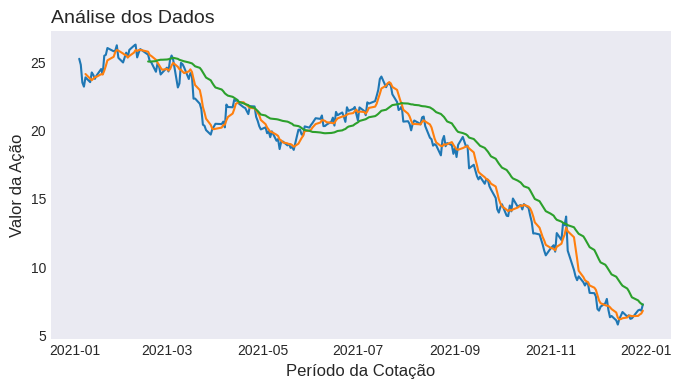

In [ ]:
Media_Movel = Dados['Fechamento'].rolling(5).mean() #Tira uma média móvel de 5 dias
Media_Tendencia = Dados['Fechamento'].rolling(30).mean() #Linha de tendencia, tirada de 30 dias

plt.figure(figsize=(8,4))
plt.style.use('seaborn-v0_8-dark')

plt.plot(Dados.index, Dados['Fechamento'])
plt.plot(Dados.index, Media_Movel)
plt.plot(Dados.index, Media_Tendencia)

plt.title('Análise dos Dados', fontsize= 14, loc='left');
plt.xlabel('Período da Cotação', fontsize= 12)
plt.ylabel('Valor da Ação', fontsize= 12)

<Axes: xlabel='Fechamento'>

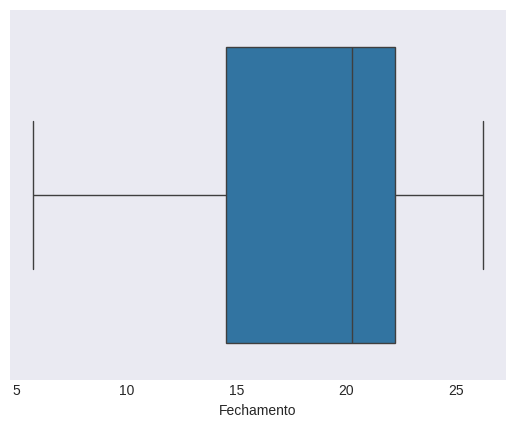

In [ ]:
sns.boxplot(data=Dados, x='Fechamento') #Não faz sentido nessa situação

<Axes: xlabel='Mes', ylabel='Fechamento'>

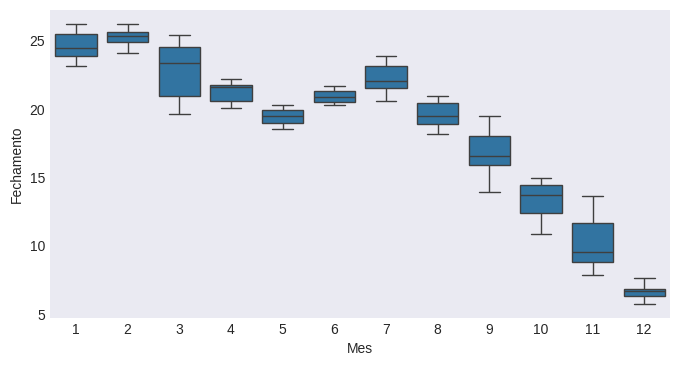

In [ ]:
Base_Mag['Mes'] = Base_Mag['Data'].dt.month #Como a data está em formato datetime é possível extrair o mes dessas datas, assim como, o ano e o dia.

plt.figure(figsize=(8, 4))
sns.boxplot(data=Base_Mag, x='Mes', y='Fechamento'); #Com isso é possivel fazer uma grafico de mes a mes


In [ ]:
Base_Mag.groupby(['Mes']).describe()['Fechamento'] #Agrupando por mes e tendo uma visão mais geral (analitica)


,count,mean,min,25%,50%,75%,max,std
Mes,,,,,,,,
1,19.0,24.644737,23.160000,23.900000,24.450001,25.455000,26.190001,0.960280
2,18.0,25.208889,24.049999,24.877501,25.299999,25.650000,26.240000,0.656021
3,23.0,22.855217,19.650000,20.940001,23.389999,24.559999,25.440001,1.976698
4,20.0,21.249000,20.030001,20.560000,21.625000,21.760000,22.200001,0.735297
5,21.0,19.430476,18.530001,18.969999,19.459999,19.900000,20.250000,0.564973
6,21.0,20.898095,20.270000,20.500000,20.889999,21.270000,21.670000,0.463116
7,21.0,22.232857,20.600000,21.530001,22.040001,23.120001,23.900000,0.977574
8,22.0,19.656818,18.129999,18.897500,19.485000,20.452499,20.969999,0.885827
9,21.0,16.746191,13.940000,15.870000,16.570000,18.010000,19.480000,1.628581


In [ ]:
#Gráfico Vela (Candlestick)
Grafico = go.Figure(
    data=[
    go.Candlestick(
        x= Dados.index,
        open= Dados['Abertura'],
        high = Dados['Maior'],
        low = Dados['Menor'],
        close = Dados['Fechamento'],
      )
   ]
)

Grafico.update_layout(xaxis_rangeslider_visible=False) #Para tirar o grafico pequeno

Grafico.show()

'''
Resultado:
Vermelho - fechou em quebra
Verde - fechou em alta
'''

'\nResultado:\nVermelho - fechou em quebra\nVerde - fechou em alta\n'